## Importing Libraries

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, roc_curve, auc

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier

## Load dataset

In [14]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.drop("customerID", axis=1, inplace=True)

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors='coerce')
df.dropna(inplace=True)

df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

df_original=df.copy()

## Exploratory Data Analysis

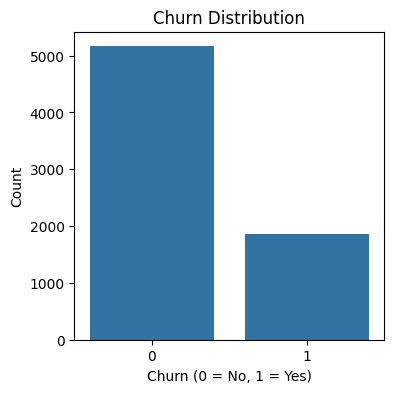

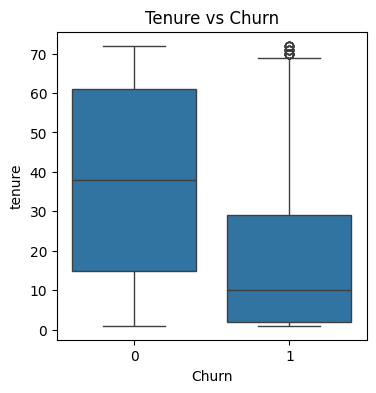

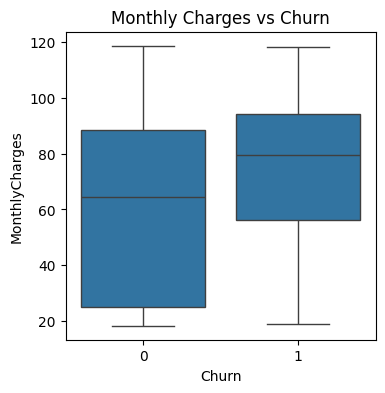

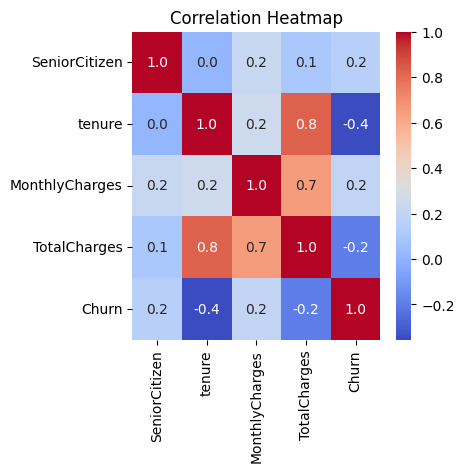

In [15]:
# Class Imbalance
plt.figure(figsize=(4,4))
sns.countplot(x="Churn", data=df)
plt.title("Churn Distribution")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

#Tenure vs churn
plt.figure(figsize=(4,4))
sns.boxplot(x="Churn", y="tenure", data=df)
plt.title("Tenure vs Churn")
plt.show()

#Monthly charges vs churn
plt.figure(figsize=(4,4))
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

#Correlation HeatMap
plt.figure(figsize=(4,4))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".1f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [16]:
# Encoding
le = LabelEncoder()

for col in df.select_dtypes(include=['object', 'string']).columns:
    df[col] = le.fit_transform(df[col])

# split data
X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
#scalling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

before_results = []


## Model

In [17]:
models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(probability=True),
    "Gradient Boosting": GradientBoostingClassifier()
}
# Heatmap
def plot_confusion_matrix(cm, title):
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["No Churn", "Churn"],
                yticklabels=["No Churn", "Churn"])
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


Before - Random Forest
Accuracy : 0.7896
Precision: 0.6383
Recall: 0.4813
F1 Score : 0.5488
Confusion Matrix:
 [[931 102]
 [194 180]]


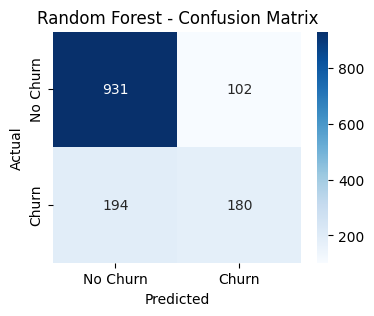

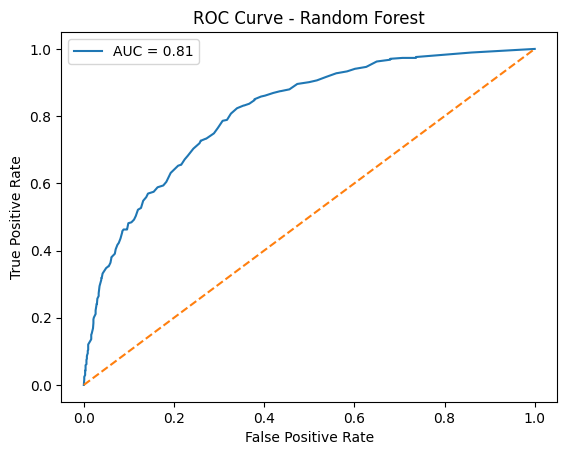


Before - KNN
Accuracy : 0.7413
Precision: 0.5134
Recall: 0.5107
F1 Score : 0.5121
Confusion Matrix:
 [[852 181]
 [183 191]]


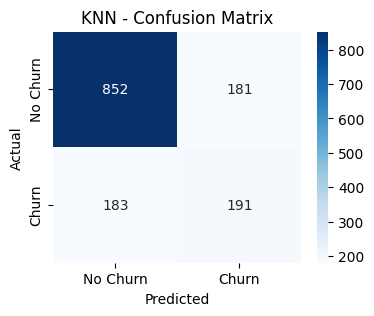

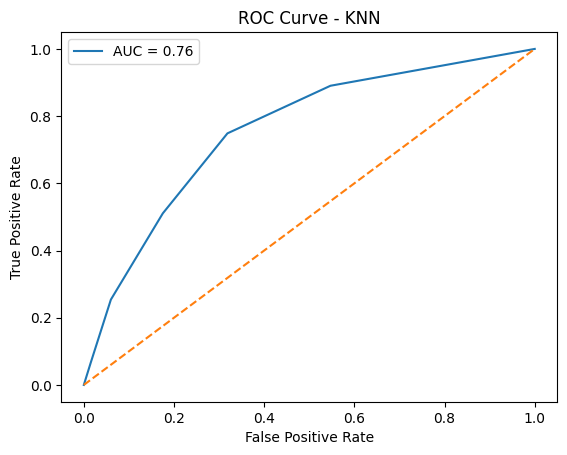


Before - SVM
Accuracy : 0.791
Precision: 0.6527
Recall: 0.4572
F1 Score : 0.5377
Confusion Matrix:
 [[942  91]
 [203 171]]


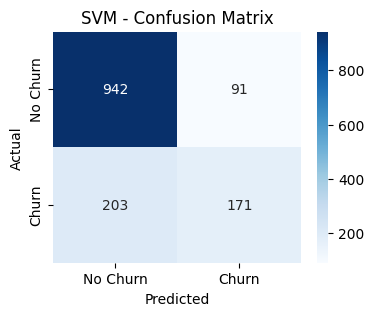

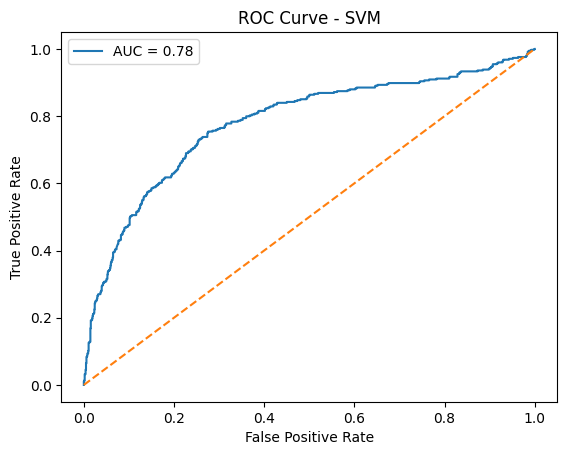


Before - Gradient Boosting
Accuracy : 0.7953
Precision: 0.6525
Recall: 0.492
F1 Score : 0.561
Confusion Matrix:
 [[935  98]
 [190 184]]


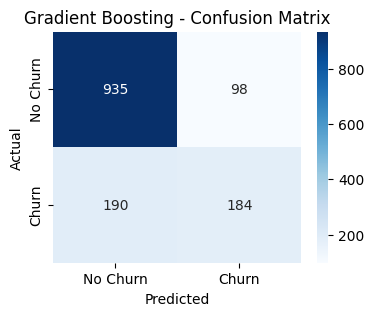

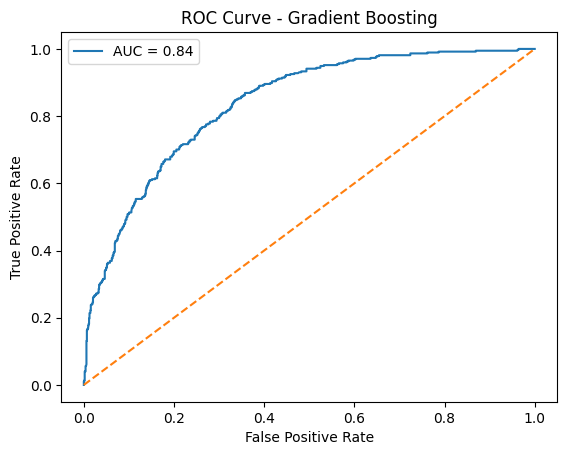

In [18]:
for name, model in models.items():
    
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    
    cm = confusion_matrix(y_test, y_pred)
    
    before_results.append([name, acc, prec, rec, f1])
    
    print(f"\nBefore - {name}")
    print("Accuracy :", round(acc,4))
    print("Precision:", round(prec,4))
    print("Recall:",round(rec,4))
    print("F1 Score :", round(f1,4))
    print("Confusion Matrix:\n",cm)
    
    plot_confusion_matrix(cm, f"{name} - Confusion Matrix")
    
    # ROC Curve (separate plot)
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    
    plt.figure()  # NEW FIGURE
    
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
    plt.plot([0,1], [0,1], linestyle='--')
    
    plt.title(f"ROC Curve - {name}")  # 👈 model name as title
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.show()

In [19]:
#Feature Engineering
df_feature = df_original.copy()

# New features
df_feature["AvgCharge"] = df_feature["TotalCharges"] / (df_feature["tenure"] + 1)
df_feature["ChargeRatio"] = df_feature["MonthlyCharges"] / (df_feature["TotalCharges"] + 1)
df_feature["TenureSquared"] = df_feature["tenure"] ** 2
df_feature["IsNewCustomer"] = (df_feature["tenure"] < 6).astype(int)
df_feature["HighSpender"] = (df_feature["MonthlyCharges"] > 70).astype(int)

In [20]:
#Repeat preprocessing 
for col in df_feature.select_dtypes(include=['object', 'string']):
    le = LabelEncoder()
    df_feature[col] = le.fit_transform(df_feature[col])


Running model: Random Forest
Accuracy : 0.7733
Precision: 0.5726
Recall   : 0.5802
F1 Score : 0.5764


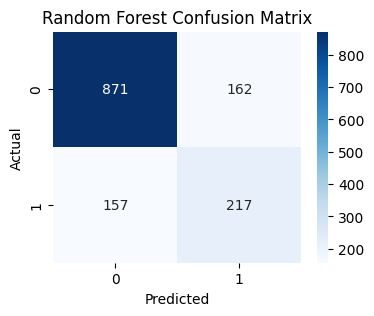

AUC: 0.8154


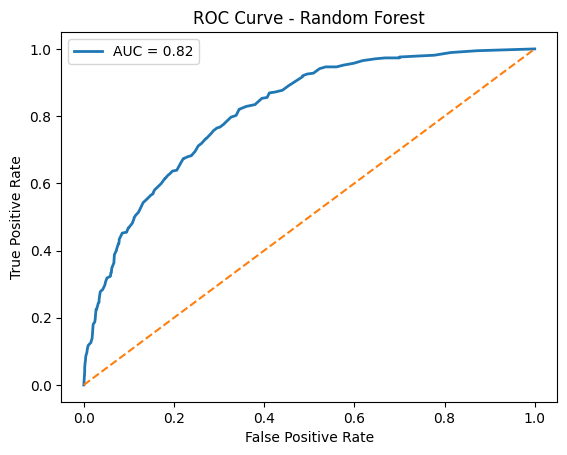


Running model: KNN
Accuracy : 0.6937
Precision: 0.4467
Recall   : 0.6390
F1 Score : 0.5259


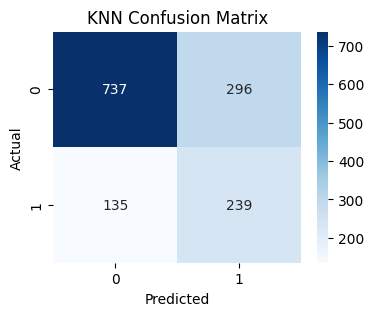

AUC: 0.7499


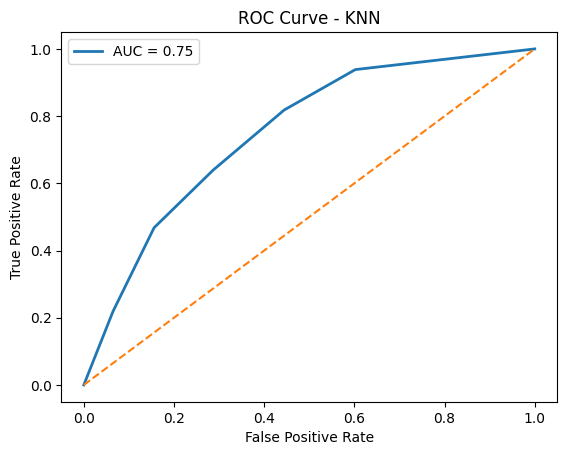


Running model: SVM
Accuracy : 0.7441
Precision: 0.5148
Recall   : 0.6497
F1 Score : 0.5745


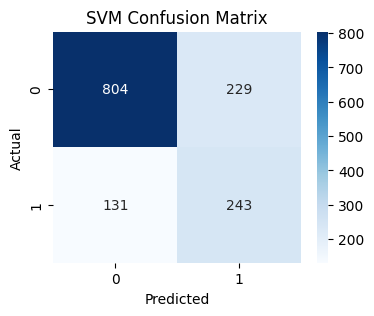

AUC: 0.7972


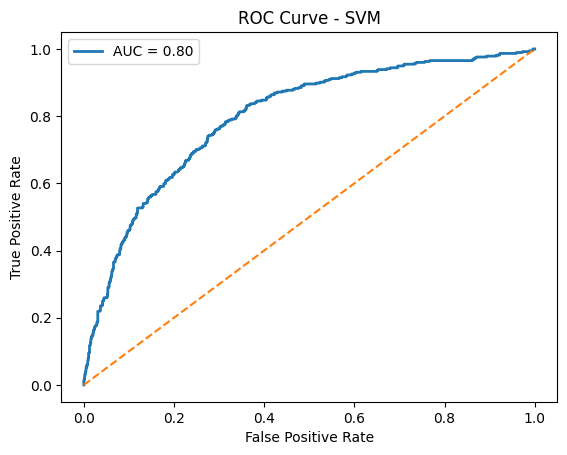


Running model: Gradient Boosting
Accuracy : 0.7512
Precision: 0.5249
Recall   : 0.6765
F1 Score : 0.5911


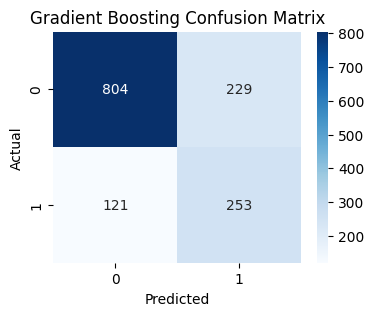

AUC: 0.8200


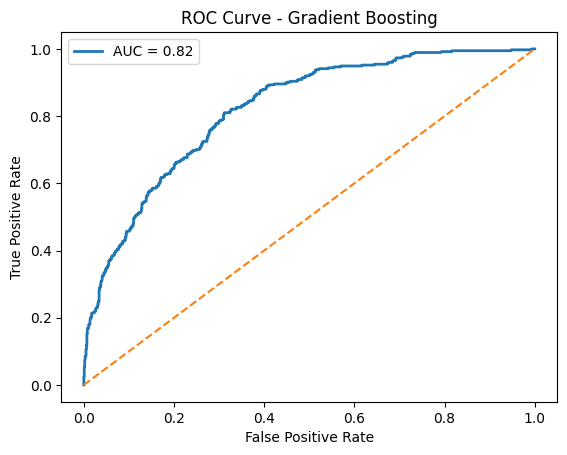

In [21]:
#splitting data

from imblearn.over_sampling import SMOTE
X = df_feature.drop("Churn", axis=1)
y = df_feature["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
#smote
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

#scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_sm)
X_test_scaled = scaler.transform(X_test)

results = []

for name, model in models.items():
    
    print("\nRunning model:", name)
    
    # Train
    model.fit(X_train_scaled, y_train_sm)
    
    # Predict
    y_pred = model.predict(X_test_scaled)
    
    # Probabilities
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_prob = model.decision_function(X_test_scaled)
    
    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    
    results.append([name, acc, prec, rec, f1])
    
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1 Score : {f1:.4f}")
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()
    
    # ROC Curve (separate)
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    
    print(f"AUC: {roc_auc:.4f}")
    
    plt.figure()
    plt.plot(fpr, tpr, linewidth=2, label=f"AUC = {roc_auc:.2f}")
    plt.plot([0,1], [0,1], linestyle="--")
    
    plt.title(f"ROC Curve - {name}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.show()

In [22]:
#Comparing results
before_df = pd.DataFrame(
    before_results,
    columns=["Model", "Accuracy Before", "Precision Before", "Recall Before", "F1 Before"]
)

after_df = pd.DataFrame(
    results,
    columns=["Model", "Accuracy After", "Precision After", "Recall After", "F1 After"]
)

comparison = pd.merge(before_df, after_df, on="Model")

print("\nBefore vs After Comparison:\n")
print(comparison)


Before vs After Comparison:

               Model  Accuracy Before  Precision Before  Recall Before  \
0      Random Forest         0.789623          0.638298       0.481283   
1                KNN         0.741294          0.513441       0.510695   
2                SVM         0.791045          0.652672       0.457219   
3  Gradient Boosting         0.795309          0.652482       0.491979   

   F1 Before  Accuracy After  Precision After  Recall After  F1 After  
0   0.548780        0.773276         0.572559      0.580214  0.576361  
1   0.512064        0.693674         0.446729      0.639037  0.525853  
2   0.537736        0.744136         0.514831      0.649733  0.574468  
3   0.560976        0.751244         0.524896      0.676471  0.591121  


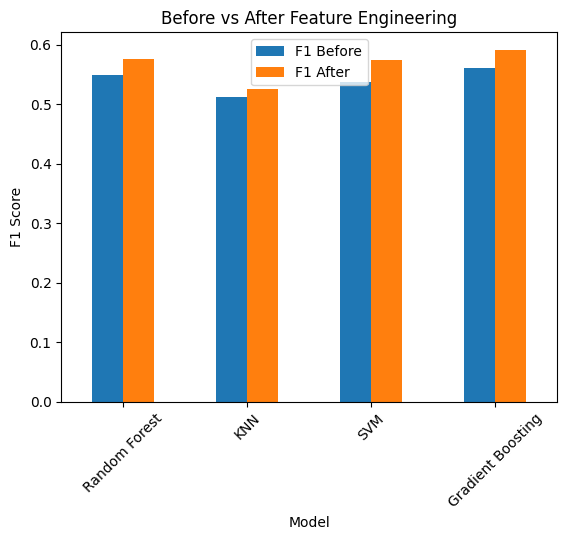

In [23]:
#Visual comparision
comparison.set_index("Model")[["F1 Before", "F1 After"]].plot(kind="bar")

plt.title("Before vs After Feature Engineering")
plt.ylabel("F1 Score")
plt.xticks(rotation=45)
plt.show()

In [24]:
# ==============================
# FINAL CONCLUSION
# ==============================

# Find best model based on F1 AFTER feature engineering
best_model = comparison.loc[comparison["F1 After"].idxmax()]

print("\n Final Conclusion:")
print("Best Model:", best_model["Model"])
print("F1 Score :", round(best_model["F1 After"],4))
print("Accuracy :", round(best_model["Accuracy After"],4))


 Final Conclusion:
Best Model: Gradient Boosting
F1 Score : 0.5911
Accuracy : 0.7512
